# Understanding and Implementing Diffusion Models

This notebook provides a comprehensive introduction to **Denoising Diffusion Probabilistic Models (DDPMs)**. We'll implement a diffusion model from scratch and train it on the MNIST dataset.

## Table of Contents
1. [Theory: What are Diffusion Models?](#theory)
2. [Setup and Imports](#setup)
3. [Forward Diffusion Process](#forward)
4. [Model Architecture (U-Net)](#architecture)
5. [Training the Model](#training)
6. [Reverse Diffusion (Sampling)](#sampling)
7. [Visualizations and Results](#results)

## 1. Theory: What are Diffusion Models? <a name="theory"></a>

### The Core Idea

Diffusion models work by gradually adding noise to data (forward process) and then learning to reverse this process (reverse process):

**Forward Process (Fixed):**
- Start with real data $x_0$
- Gradually add Gaussian noise over $T$ timesteps
- End with pure noise $x_T \sim \mathcal{N}(0, I)$

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

**Reverse Process (Learned):**
- Start with pure noise $x_T$
- Gradually denoise over $T$ timesteps
- End with generated data $x_0$

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta(x_t, t))$$

### Key Properties

1. **Variance Schedule:** $\beta_t$ controls noise added at each step
2. **Reparameterization:** We predict noise $\epsilon$ instead of the mean
3. **Training Objective:** Simple MSE loss between predicted and actual noise

## 2. Setup and Imports <a name="setup"></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
IMG_SIZE = 28
BATCH_SIZE = 128
TIMESTEPS = 1000
EPOCHS = 20
LEARNING_RATE = 2e-4

Using device: cuda


### Load and Visualize Dataset

100%|██████████| 9.91M/9.91M [00:11<00:00, 831kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 108kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 702kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.53MB/s]


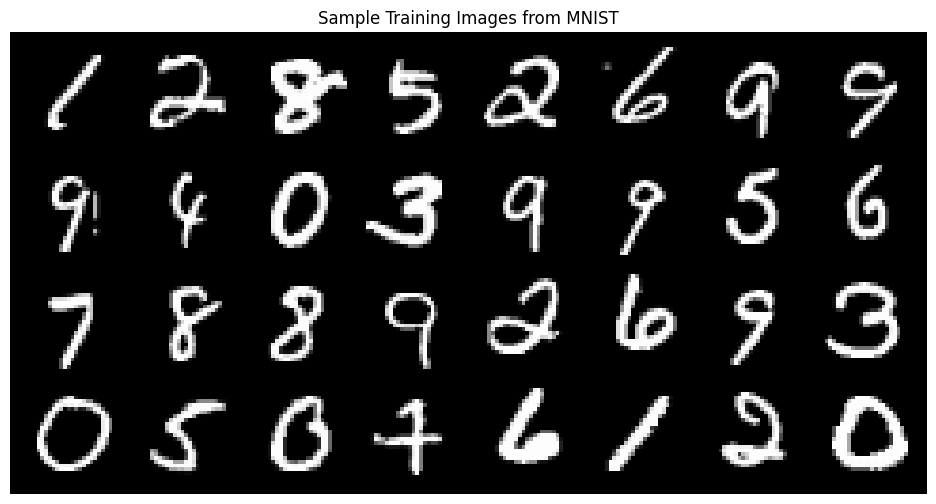

In [2]:
# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale to [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# Visualize sample images
def show_images(images, title=""):
    images = (images + 1) / 2  # Denormalize from [-1,1] to [0,1]
    grid = make_grid(images, nrow=8)
    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show some training examples
sample_batch = next(iter(train_loader))[0][:32]
show_images(sample_batch, "Sample Training Images from MNIST")

## 3. Forward Diffusion Process <a name="forward"></a>

The forward process gradually adds noise to images. We use a **variance schedule** that determines how much noise to add at each timestep.

### Beta Schedule

We'll use a **linear schedule** where $\beta_t$ increases linearly from $\beta_1$ to $\beta_T$.

### Key Variables:
- $\alpha_t = 1 - \beta_t$
- $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ (cumulative product)

This allows us to sample $x_t$ directly from $x_0$:

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

In [3]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Linear schedule for beta values"""
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule as proposed in https://arxiv.org/abs/2102.09672"""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

# Prepare noise schedule
betas = linear_beta_schedule(TIMESTEPS)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

# Calculations for diffusion q(x_t | x_{t-1})
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(arr, timesteps, broadcast_shape):
    """Extract values from arr at timesteps and reshape for broadcasting"""
    res = arr.gather(-1, timesteps.cpu())
    return res.reshape(timesteps.shape[0], *((1,) * (len(broadcast_shape) - 1))).to(timesteps.device)

### Visualize the Forward Process

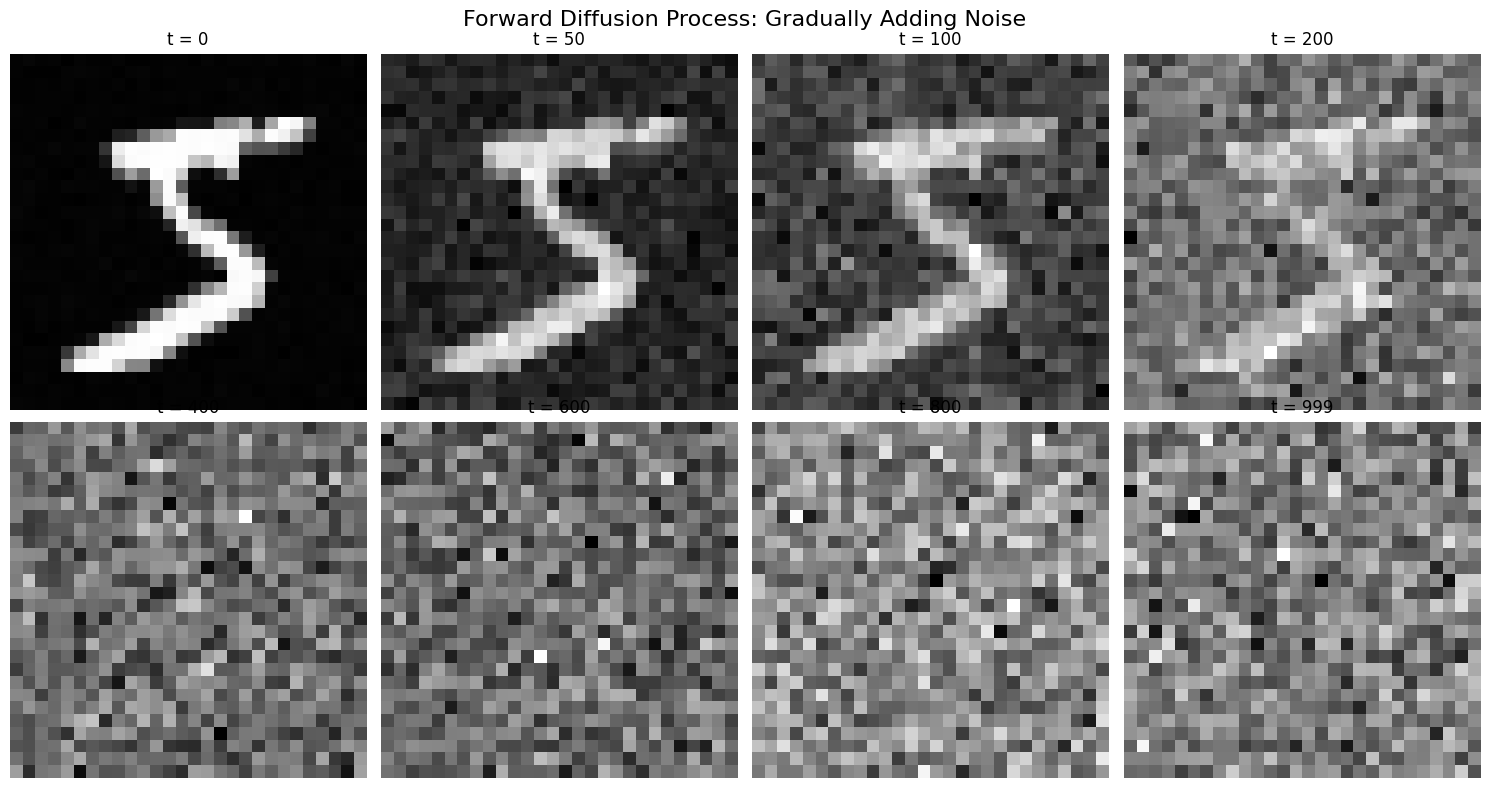

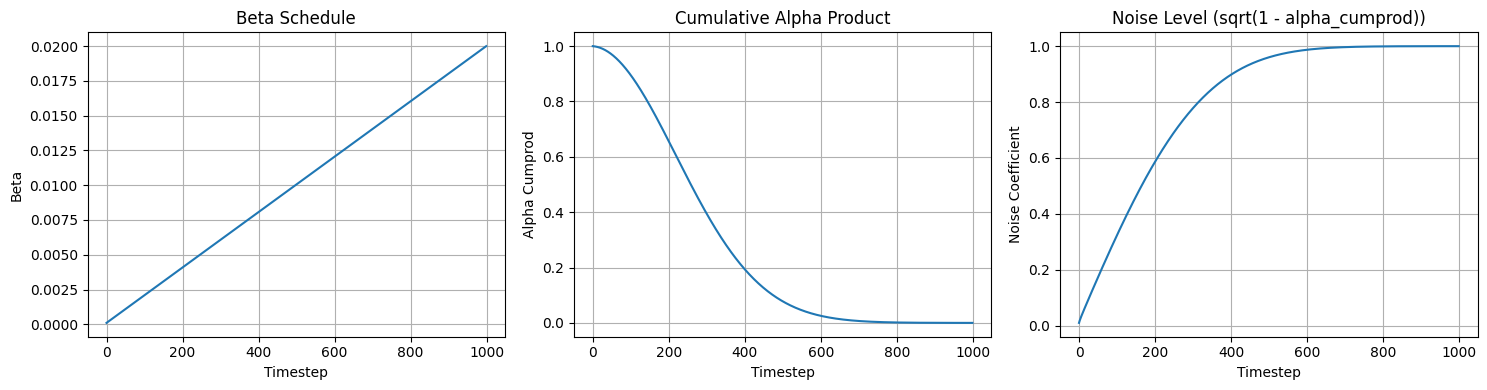

In [4]:
def forward_diffusion(x_0, t, noise=None):
    """Apply forward diffusion to add noise to x_0 at timestep t"""
    if noise is None:
        noise = torch.randn_like(x_0)
    
    sqrt_alpha_cumprod_t = extract(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alpha_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    return sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise, noise

# Visualize forward process
sample_image = train_dataset[0][0].unsqueeze(0).to(device)
timesteps_to_show = [0, 50, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for idx, t in enumerate(timesteps_to_show):
    t_tensor = torch.tensor([t], device=device)
    noisy_image, _ = forward_diffusion(sample_image, t_tensor)
    
    img = noisy_image.squeeze().cpu()
    img = (img + 1) / 2  # Denormalize
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f't = {t}')
    axes[idx].axis('off')

plt.suptitle('Forward Diffusion Process: Gradually Adding Noise', fontsize=16)
plt.tight_layout()
plt.show()

# Visualize beta schedule
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(betas.numpy())
axes[0].set_title('Beta Schedule')
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Beta')
axes[0].grid(True)

axes[1].plot(alphas_cumprod.numpy())
axes[1].set_title('Cumulative Alpha Product')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Alpha Cumprod')
axes[1].grid(True)

axes[2].plot(sqrt_one_minus_alphas_cumprod.numpy())
axes[2].set_title('Noise Level (sqrt(1 - alpha_cumprod))')
axes[2].set_xlabel('Timestep')
axes[2].set_ylabel('Noise Coefficient')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 4. Model Architecture: U-Net <a name="architecture"></a>

We use a **U-Net architecture** with:
- **Time embeddings**: Sinusoidal positional encodings for timestep information
- **Residual blocks**: With GroupNorm and time conditioning
- **Attention mechanisms**: Self-attention at specific resolutions
- **Skip connections**: From encoder to decoder

The model takes:
- Input: Noisy image $x_t$ and timestep $t$
- Output: Predicted noise $\epsilon_\theta(x_t, t)$

In [5]:
class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal time embeddings for timestep conditioning"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    """Residual block with time conditioning"""
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)
        
        self.act = nn.SiLU()
        
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)
        
        # Add time conditioning
        time_emb = self.act(self.time_mlp(time_emb))
        h = h + time_emb[:, :, None, None]
        
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)
        
        return h + self.residual_conv(x)

class AttentionBlock(nn.Module):
    """Self-attention block"""
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h)
        q, k, v = qkv.chunk(3, dim=1)
        
        # Reshape for attention
        q = q.reshape(B, C, H * W).permute(0, 2, 1)
        k = k.reshape(B, C, H * W)
        v = v.reshape(B, C, H * W).permute(0, 2, 1)
        
        # Attention
        scale = C ** -0.5
        attn = torch.softmax(torch.bmm(q, k) * scale, dim=-1)
        h = torch.bmm(attn, v)
        
        h = h.permute(0, 2, 1).reshape(B, C, H, W)
        h = self.proj(h)
        
        return x + h

class UNet(nn.Module):
    """U-Net architecture for diffusion models"""
    def __init__(self, img_channels=1, base_channels=64, time_emb_dim=256):
        super().__init__()
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_channels),
            nn.Linear(base_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )
        
        # Initial convolution
        self.conv0 = nn.Conv2d(img_channels, base_channels, 3, padding=1)
        
        # Encoder (downsampling)
        self.down1 = ResidualBlock(base_channels, base_channels, time_emb_dim)
        self.down2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down3 = ResidualBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck with attention
        self.bottleneck1 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim)
        self.attention = AttentionBlock(base_channels * 4)
        self.bottleneck2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        
        # Decoder (upsampling)
        self.up1 = ResidualBlock(base_channels * 6, base_channels * 2, time_emb_dim)
        self.up2 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim)
        self.up3 = ResidualBlock(base_channels * 3, base_channels, time_emb_dim)
        
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        
        # Output
        self.output = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, img_channels, 1),
        )

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_mlp(t)
        
        # Initial convolution
        x = self.conv0(x)
        
        # Encoder
        skip1 = self.down1(x, t_emb)
        x = self.pool(skip1)
        
        skip2 = self.down2(x, t_emb)
        x = self.pool(skip2)
        
        skip3 = self.down3(x, t_emb)
        x = self.pool(skip3)
        
        # Bottleneck
        x = self.bottleneck1(x, t_emb)
        x = self.attention(x)
        x = self.bottleneck2(x, t_emb)
        
        # Decoder
        x = self.upsample(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.up1(x, t_emb)
        
        x = self.upsample(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.up2(x, t_emb)
        
        x = self.upsample(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.up3(x, t_emb)
        
        # Output
        return self.output(x)

# Initialize model
model = UNet().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 4,619,649


## 5. Training the Model <a name="training"></a>

### Training Algorithm:

1. Sample a batch of images $x_0$ from the dataset
2. Sample random timesteps $t \sim \text{Uniform}(1, T)$
3. Sample noise $\epsilon \sim \mathcal{N}(0, I)$
4. Create noisy images: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$
5. Predict noise: $\epsilon_\theta(x_t, t)$
6. Compute loss: $L = ||\epsilon - \epsilon_\theta(x_t, t)||^2$
7. Update model parameters

This is much simpler than the full ELBO loss in the original paper!

In [6]:
def train_step(model, x_0, optimizer):
    """Single training step"""
    optimizer.zero_grad()
    
    batch_size = x_0.shape[0]
    
    # Sample random timesteps
    t = torch.randint(0, TIMESTEPS, (batch_size,), device=device).long()
    
    # Sample noise
    noise = torch.randn_like(x_0)
    
    # Add noise to images
    x_t, _ = forward_diffusion(x_0, t, noise)
    
    # Predict noise
    predicted_noise = model(x_t, t)
    
    # Compute loss
    loss = F.mse_loss(predicted_noise, noise)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return loss.item()

# Training setup
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Training loop
losses = []
epoch_losses = []

print("Starting training...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch_idx, (images, _) in enumerate(pbar):
        images = images.to(device)
        
        loss = train_step(model, images, optimizer)
        losses.append(loss)
        epoch_loss += loss
        
        pbar.set_postfix({'loss': f'{loss:.4f}'})
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_epoch_loss)
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Average Loss: {avg_epoch_loss:.4f}")
    
    # Generate samples every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Generating samples at epoch {epoch+1}...")

print("\nTraining complete!")

Starting training...



Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 6 but got size 7 for tensor number 1 in the list.

### Visualize Training Progress

In [ ]:
# Plot training loss
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(losses, alpha=0.3, label='Batch Loss')
# Running average
window = 100
running_avg = np.convolve(losses, np.ones(window)/window, mode='valid')
axes[0].plot(range(window-1, len(losses)), running_avg, linewidth=2, label='Running Average')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epoch_losses, marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Average Loss')
axes[1].set_title('Average Loss per Epoch')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Reverse Diffusion (Sampling) <a name="sampling"></a>

To generate images, we reverse the diffusion process:

1. Start with pure noise $x_T \sim \mathcal{N}(0, I)$
2. For $t = T, T-1, ..., 1$:
   - Predict noise: $\epsilon_\theta(x_t, t)$
   - Compute mean: $\mu_\theta(x_t, t)$
   - Sample: $x_{t-1} = \mu_\theta(x_t, t) + \sigma_t z$ where $z \sim \mathcal{N}(0, I)$
3. Return $x_0$

The mean can be computed from the predicted noise using the reparameterization:

$$\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)$$

In [ ]:
@torch.no_grad()
def sample_timestep(model, x, t):
    """Sample x_{t-1} given x_t using the model"""
    # Get batch size
    bsz = x.shape[0]
    
    # Predict noise
    predicted_noise = model(x, t)
    
    # Get parameters for this timestep
    alpha_t = extract(alphas, t, x.shape)
    alpha_cumprod_t = extract(alphas_cumprod, t, x.shape)
    beta_t = extract(betas, t, x.shape)
    sqrt_one_minus_alpha_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    
    # Compute mean
    model_mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / sqrt_one_minus_alpha_cumprod_t) * predicted_noise)
    
    if t[0] == 0:
        return model_mean
    else:
        # Add noise
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def sample_images(model, n_samples=16, show_process=False):
    """Generate images by reversing the diffusion process"""
    model.eval()
    
    # Start from pure noise
    img = torch.randn((n_samples, 1, IMG_SIZE, IMG_SIZE), device=device)
    
    # Store intermediate steps for visualization
    steps_to_show = [999, 800, 600, 400, 200, 100, 50, 0]
    intermediate_images = []
    
    # Reverse diffusion
    for i in tqdm(reversed(range(TIMESTEPS)), desc='Sampling', total=TIMESTEPS):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        img = sample_timestep(model, img, t)
        
        if show_process and i in steps_to_show:
            intermediate_images.append(img.cpu().clone())
    
    if show_process:
        return img, intermediate_images
    return img

# Generate samples
print("Generating images...")
generated_images, intermediate = sample_images(model, n_samples=32, show_process=True)
print("Generation complete!")

## 7. Visualizations and Results <a name="results"></a>

### Reverse Process Visualization

Watch how the model gradually denoises pure noise into recognizable digits!

In [ ]:
# Visualize the reverse process
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

steps_labels = [999, 800, 600, 400, 200, 100, 50, 0]

for idx, (imgs, step) in enumerate(zip(intermediate, steps_labels)):
    img = imgs[0].squeeze()
    img = (img + 1) / 2  # Denormalize
    img = torch.clamp(img, 0, 1)
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f't = {step}')
    axes[idx].axis('off')

plt.suptitle('Reverse Diffusion Process: From Noise to Image', fontsize=16)
plt.tight_layout()
plt.show()

### Generated Samples Gallery

In [ ]:
# Show all generated samples
show_images(generated_images, "Generated MNIST Digits")

### Compare Real vs Generated Images

In [ ]:
# Compare real and generated
real_samples = next(iter(train_loader))[0][:16].to(device)
generated_samples = sample_images(model, n_samples=16)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Real images
real_grid = make_grid((real_samples + 1) / 2, nrow=8)
axes[0].imshow(real_grid.permute(1, 2, 0).cpu())
axes[0].set_title('Real Images from MNIST', fontsize=14)
axes[0].axis('off')

# Generated images
gen_grid = make_grid((generated_samples + 1) / 2, nrow=8)
axes[1].imshow(gen_grid.permute(1, 2, 0).cpu())
axes[1].set_title('Generated Images from Diffusion Model', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Interpolation in Noise Space

We can interpolate between two noise vectors to see smooth transitions between generated images.

In [ ]:
@torch.no_grad()
def interpolate_noise(model, n_steps=8):
    """Generate images by interpolating between two noise vectors"""
    model.eval()
    
    # Two random noise vectors
    noise1 = torch.randn((1, 1, IMG_SIZE, IMG_SIZE), device=device)
    noise2 = torch.randn((1, 1, IMG_SIZE, IMG_SIZE), device=device)
    
    # Interpolate
    alphas_interp = torch.linspace(0, 1, n_steps, device=device)
    interpolated_images = []
    
    for alpha in alphas_interp:
        # Spherical interpolation (better for normalized spaces)
        noise_interp = (1 - alpha) * noise1 + alpha * noise2
        img = noise_interp
        
        # Reverse diffusion
        for i in reversed(range(TIMESTEPS)):
            t = torch.full((1,), i, device=device, dtype=torch.long)
            img = sample_timestep(model, img, t)
        
        interpolated_images.append(img.cpu())
    
    return torch.cat(interpolated_images, dim=0)

# Generate interpolation
print("Generating interpolation...")
interp_images = interpolate_noise(model, n_steps=8)
show_images(interp_images, "Interpolation in Noise Space")

### Model Learned Denoising at Different Noise Levels

Let's visualize what the model predicts at different stages of the diffusion process.

In [ ]:
@torch.no_grad()
def show_denoising_capability(model, n_samples=4):
    """Show model's denoising predictions at different timesteps"""
    model.eval()
    
    # Get real images
    real_images = next(iter(train_loader))[0][:n_samples].to(device)
    timesteps_to_test = [100, 300, 500, 700, 900]
    
    fig, axes = plt.subplots(n_samples, len(timesteps_to_test) + 2, figsize=(18, 3 * n_samples))
    
    for i in range(n_samples):
        img = real_images[i:i+1]
        
        # Show original
        axes[i, 0].imshow(((img.squeeze().cpu() + 1) / 2), cmap='gray')
        axes[i, 0].set_title('Original' if i == 0 else '')
        axes[i, 0].axis('off')
        
        for j, t_val in enumerate(timesteps_to_test):
            t = torch.tensor([t_val], device=device)
            
            # Add noise
            noisy_img, noise = forward_diffusion(img, t)
            
            # Predict noise
            predicted_noise = model(noisy_img, t)
            
            # Compute denoised estimate
            alpha_cumprod_t = extract(alphas_cumprod, t, img.shape)
            sqrt_alpha_cumprod_t = torch.sqrt(alpha_cumprod_t)
            sqrt_one_minus_alpha_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, img.shape)
            
            denoised = (noisy_img - sqrt_one_minus_alpha_cumprod_t * predicted_noise) / sqrt_alpha_cumprod_t
            
            # Display
            denoised_img = (denoised.squeeze().cpu() + 1) / 2
            denoised_img = torch.clamp(denoised_img, 0, 1)
            
            axes[i, j + 1].imshow(denoised_img, cmap='gray')
            axes[i, j + 1].set_title(f't={t_val}' if i == 0 else '')
            axes[i, j + 1].axis('off')
        
        # Show noisy version at t=900
        t_final = torch.tensor([900], device=device)
        noisy_final, _ = forward_diffusion(img, t_final)
        axes[i, -1].imshow(((noisy_final.squeeze().cpu() + 1) / 2), cmap='gray')
        axes[i, -1].set_title('Noisy (t=900)' if i == 0 else '')
        axes[i, -1].axis('off')
    
    plt.suptitle('Model Denoising Predictions at Different Timesteps', fontsize=16)
    plt.tight_layout()
    plt.show()

show_denoising_capability(model, n_samples=4)

## Summary and Key Takeaways

### What We Learned:

1. **Forward Process**: We progressively add Gaussian noise to images over T timesteps
2. **Reverse Process**: We train a neural network to predict and remove noise
3. **Training**: Simple MSE loss between predicted and actual noise
4. **Sampling**: Start from noise and iteratively denoise to generate new images

### Key Advantages of Diffusion Models:

- **Stable Training**: Unlike GANs, no adversarial training
- **High Quality**: State-of-the-art generation quality
- **Flexible**: Easy to condition on labels, text, etc.
- **Interpretable**: Clear forward and reverse processes

### Extensions to Explore:

1. **Conditional Generation**: Add class labels to generate specific digits
2. **Faster Sampling**: DDIM, DPM-Solver for fewer steps
3. **Better Schedules**: Cosine schedule, learned variance
4. **Latent Diffusion**: Work in compressed latent space (like Stable Diffusion)
5. **Guidance**: Classifier-free guidance for better control

### Resources:

- Original Paper: [Denoising Diffusion Probabilistic Models (Ho et al., 2020)](https://arxiv.org/abs/2006.11239)
- Improved Techniques: [Improved Denoising Diffusion Probabilistic Models (Nichol & Dhariwal, 2021)](https://arxiv.org/abs/2102.09672)
- Survey: [Understanding Diffusion Models (Luo, 2022)](https://arxiv.org/abs/2208.11970)

## Save the Model

In [ ]:
# Save model checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': EPOCHS,
    'loss': epoch_losses[-1],
}, 'diffusion_model_mnist.pth')

print("Model saved to 'diffusion_model_mnist.pth'")

## Experiments to Try

Now that you understand the basics, try these experiments:

1. **Change the timesteps**: Try T=500 or T=2000 and see how it affects quality
2. **Modify architecture**: Add more residual blocks or change channel dimensions
3. **Different datasets**: Try CIFAR-10 or Fashion-MNIST
4. **Cosine schedule**: Replace linear beta schedule with cosine
5. **Conditional generation**: Add class conditioning to generate specific digits
6. **Measure FID**: Compute Frechet Inception Distance to quantify quality

## Results Snapshot
- Sampling outputs illustrate denoising progression and final generation quality.
- Hyperparameter effects are reflected in the reported training/sampling logs.
- Results shown are reused from saved notebook outputs to avoid retraining.